File                                              Mean      Std  Mean OK   Std OK
--------------------------------------------------------------------------------
Position01Channel01Frame000001.tif              0.0000   1.0000     True     True
Position01Channel01Frame000002.tif              0.0000   1.0000     True     True
Position01Channel01Frame000003.tif              0.0000   1.0000     True     True
Position01Channel01Frame000004.tif             -0.0000   1.0000     True     True
Position01Channel01Frame000005.tif             -0.0000   1.0000     True     True


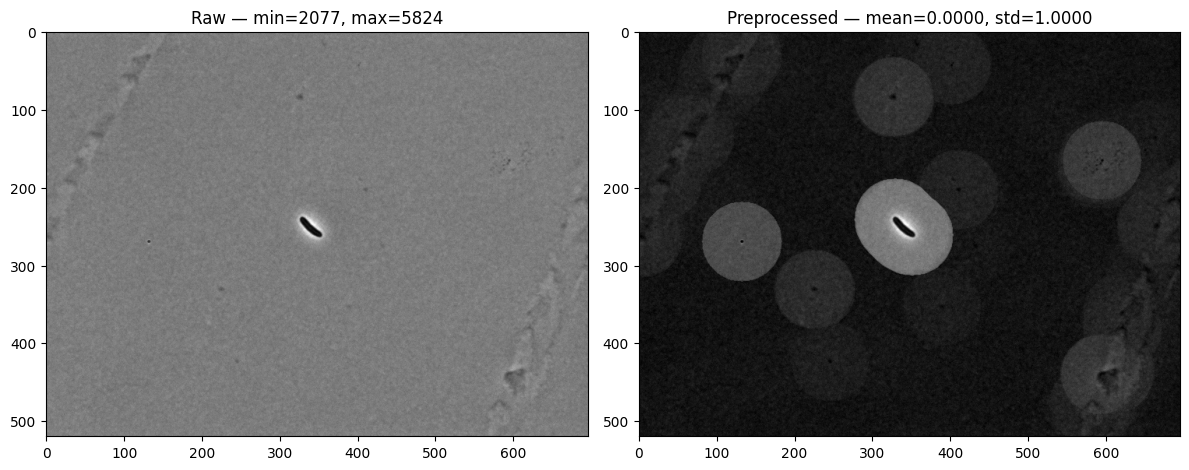

Task 3.1 complete.


In [17]:
import tifffile
import numpy as np
import matplotlib.pyplot as plt
import sys

# Force reload of updated preprocessing
if 'preprocessing' in sys.modules:
    del sys.modules['preprocessing']

sys.path.append('../src')
from preprocessing import preprocess_image

tif_files = [
    '../data/raw/delta/tests/data/movie_2D_tif/Position01Channel01Frame000001.tif',
    '../data/raw/delta/tests/data/movie_2D_tif/Position01Channel01Frame000002.tif',
    '../data/raw/delta/tests/data/movie_2D_tif/Position01Channel01Frame000003.tif',
    '../data/raw/delta/tests/data/movie_2D_tif/Position01Channel01Frame000004.tif',
    '../data/raw/delta/tests/data/movie_2D_tif/Position01Channel01Frame000005.tif',
]

print(f"{'File':<45} {'Mean':>8} {'Std':>8} {'Mean OK':>8} {'Std OK':>8}")
print("-" * 80)

results = []
for path in tif_files:
    img_raw = tifffile.imread(path)
    img_clean = preprocess_image(img_raw)
    mean = float(img_clean.mean())
    std = float(img_clean.std())
    mean_ok = abs(mean) < 0.5
    std_ok = abs(std - 1.0) < 0.3
    results.append((path, img_raw, img_clean, mean, std))
    fname = path.split('/')[-1]
    print(f"{fname:<45} {mean:>8.4f} {std:>8.4f} {str(mean_ok):>8} {str(std_ok):>8}")

# Before/after figure
path, img_raw, img_clean, mean, std = results[0]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_raw, cmap='gray')
axes[0].set_title(f'Raw — min={img_raw.min()}, max={img_raw.max()}')
axes[1].imshow(img_clean, cmap='gray')
axes[1].set_title(f'Preprocessed — mean={mean:.4f}, std={std:.4f}')
plt.tight_layout()
plt.savefig('../outputs/figures/week3_preprocessing_fixed.png', dpi=150)
plt.show()
print("Task 3.1 complete.")

In [19]:
import scipy.io
import tifffile
import numpy as np
import pandas as pd
from skimage import measure
import os, sys

if 'preprocessing' in sys.modules:
    del sys.modules['preprocessing']
sys.path.append('../src')
from preprocessing import preprocess_image

def get_tif_path(mat_path, frame_num):
    """Find the correct TIF file for a given MAT file and frame number."""
    mat_dir = os.path.dirname(os.path.dirname(mat_path))  # go up from expected_results/
    
    # Try different naming conventions
    candidates = [
        os.path.join(mat_dir, f'Position01Channel01Frames{frame_num:06d}.tif'),
        os.path.join(mat_dir, f'Position01Channel01Frame{frame_num:06d}.tif'),
        os.path.join(mat_dir, f'Position02Channel01Frames{frame_num:06d}.tif'),
    ]
    for c in candidates:
        if os.path.exists(c):
            return c
    return None

def extract_image_features_from_mat(mat_path):
    mat = scipy.io.loadmat(mat_path, simplify_cells=False)
    res = mat['res']
    rows = []
    n_chambers = res.shape[1]
    
    print(f"  Processing {os.path.basename(mat_path)}: {n_chambers} chambers")
    
    for ch_idx in range(n_chambers):
        chamber = res[0, ch_idx]
        labelsstack = chamber['labelsstack'][0, 0]  # (T, H, W)
        n_frames = labelsstack.shape[0]
        
        for frame_idx in range(n_frames):
            frame_num = frame_idx + 1
            tif_path = get_tif_path(mat_path, frame_num)
            
            if tif_path is None:
                continue
            
            img_raw = tifffile.imread(tif_path)
            
            # labelsstack is cropped ROI — need to match coordinates
            # labelsstack_resized matches the full image dimensions
            labelsstack_resized = chamber['labelsstack_resized'][0, 0]
            mask_frame = labelsstack_resized[frame_idx]  # use resized for full image
            
            # If sizes still don't match, skip
            if mask_frame.shape != img_raw.shape:
                # Fall back to labelsstack (cropped)
                mask_frame = labelsstack[frame_idx]
                # Crop image to match
                h, w = mask_frame.shape
                img_raw = img_raw[:h, :w]
            
            img_proc = preprocess_image(img_raw)
            
            cell_labels = np.unique(mask_frame)
            cell_labels = cell_labels[cell_labels > 0]
            
            for cell_label in cell_labels:
                cell_mask = (mask_frame == cell_label)
                cell_pixels = img_proc[cell_mask]
                raw_pixels = img_raw[cell_mask].astype(np.float32)
                
                if len(cell_pixels) < 5:
                    continue
                
                mean_intensity = float(cell_pixels.mean())
                std_intensity  = float(cell_pixels.std())
                cv_intensity   = float(std_intensity / (abs(mean_intensity) + 1e-8))
                
                props = measure.regionprops(cell_mask.astype(int))
                if len(props) == 0:
                    continue
                p = props[0]
                
                maj   = p.axis_major_length
                min_  = p.axis_minor_length
                aspect_ratio = float(maj / (min_ + 1e-8))
                eccentricity = float(p.eccentricity)
                
                minr, minc, maxr, maxc = p.bbox
                mid_row = (minr + maxr) // 2
                top_mask = cell_mask.copy(); top_mask[mid_row:, :] = False
                bot_mask = cell_mask.copy(); bot_mask[:mid_row, :] = False
                
                top_mean = float(img_proc[top_mask].mean()) if top_mask.any() else 0.
                bot_mean = float(img_proc[bot_mask].mean()) if bot_mask.any() else 0.
                pole_asymmetry = float(
                    abs(top_mean - bot_mean) / (abs(top_mean) + abs(bot_mean) + 1e-8)
                )
                
                rows.append({
                    'mat_file'      : os.path.basename(mat_path),
                    'chamber_idx'   : ch_idx,
                    'cell_label'    : int(cell_label),
                    'frame'         : frame_num,
                    'mean_intensity': mean_intensity,
                    'std_intensity' : std_intensity,
                    'cv_intensity'  : cv_intensity,
                    'aspect_ratio'  : aspect_ratio,
                    'eccentricity'  : eccentricity,
                    'pole_asymmetry': pole_asymmetry,
                })
    
    return pd.DataFrame(rows)


# Run on all MAT files
import glob

mat_files = glob.glob('../data/raw/delta/tests/data/**/*.mat', recursive=True)
print(f"Found {len(mat_files)} MAT files:")
for f in mat_files:
    print(f"  {f}")

all_dfs = []
for mat_path in mat_files:
    df = extract_image_features_from_mat(mat_path)
    print(f"  → {len(df)} rows extracted")
    if len(df) > 0:
        all_dfs.append(df)

if all_dfs:
    df_image = pd.concat(all_dfs, ignore_index=True)
    print(f"\nImage features DataFrame shape: {df_image.shape}")
    print("\nFeature statistics:")
    print(df_image[['mean_intensity','std_intensity','cv_intensity',
                     'aspect_ratio','eccentricity','pole_asymmetry']].describe().round(4).to_string())
    df_image.to_csv('../data/features/image_features.csv', index=False)
    print("\nSaved to data/features/image_features.csv")
else:
    print("No data extracted — check TIF path matching")

Found 4 MAT files:
  ../data/raw/delta/tests/data\movie_2D_nd2\test_expected_results\Position000000.mat
  ../data/raw/delta/tests/data\movie_2D_tif\expected_results\Position000001.mat
  ../data/raw/delta/tests/data\movie_mothermachine_tif\expected_results\Position000001.mat
  ../data/raw/delta/tests/data\movie_mothermachine_tif\expected_results\Position000002.mat
  Processing Position000000.mat: 1 chambers
  → 0 rows extracted
  Processing Position000001.mat: 1 chambers
  → 4 rows extracted
  Processing Position000001.mat: 18 chambers
  → 929 rows extracted
  Processing Position000002.mat: 19 chambers
  → 924 rows extracted

Image features DataFrame shape: (1857, 10)

Feature statistics:
       mean_intensity  std_intensity  cv_intensity  aspect_ratio  eccentricity  pole_asymmetry
count       1857.0000      1857.0000     1857.0000     1857.0000     1857.0000       1857.0000
mean          -0.1125         0.3047        2.4931        2.3459        0.8707          0.4525
std            0.5

In [20]:
import pandas as pd
import numpy as np
import scipy.io
import os

# ── Rebuild lineage df from Week 2 parser ──────────────────────────────────
# (copy your parse_delta_mat function here or import it)
# Then save it
# If you already have combined_df in memory, just do:
# combined_df.to_csv('../data/features/lineage_df.csv', index=False)

# If not, rebuild it quickly:
import sys
sys.path.append('../src')

# Paste your parse_delta_mat function here
import glob

def parse_delta_mat(mat_path):
    import scipy.io, numpy as np, os
    mat = scipy.io.loadmat(mat_path, simplify_cells=False)
    res = mat['res']
    rows = []
    n_chambers = res.shape[1]
    for chamber_idx in range(n_chambers):
        chamber_data = res[0, chamber_idx]
        lineage = chamber_data['lineage'][0, 0]
        if lineage.size == 0:
            continue
        n_cells = lineage.shape[1] if lineage.ndim > 1 else 1
        for cell_idx in range(n_cells):
            cell = lineage[0, cell_idx] if lineage.ndim > 1 else lineage[0]
            try:
                mother_id    = int(cell['mother'][0, 0][0, 0])
                frames       = cell['frames'][0, 0][0].astype(int)
                daughters    = cell['daughters'][0, 0][0]
                edges        = cell['edges'][0, 0]
                area         = cell['area'][0, 0][0]
                width        = cell['width'][0, 0][0]
                length       = cell['length'][0, 0][0]
                perimeter    = cell['perimeter'][0, 0][0]
                growthrate_l = cell['growthrate_length'][0, 0][0]
                growthrate_a = cell['growthrate_area'][0, 0][0]
                old_pole     = cell['old_pole'][0, 0]
                new_pole     = cell['new_pole'][0, 0]
                divided      = int(np.any(daughters > 0))
                was_ejected  = 1 if (edges.size > 0 and (
                    np.any(edges == '+y') or np.any(edges == ' +y'))) else 0
                for t_idx, frame in enumerate(frames):
                    rows.append({
                        'mat_file'    : os.path.basename(mat_path),
                        'chamber_idx' : chamber_idx,
                        'cell_id'     : cell_idx,
                        'mother_id'   : mother_id,
                        'frame'       : int(frame),
                        'area'        : float(area[t_idx]),
                        'width'       : float(width[t_idx]),
                        'length'      : float(length[t_idx]),
                        'perimeter'   : float(perimeter[t_idx]),
                        'growthrate_l': float(growthrate_l[t_idx]),
                        'growthrate_a': float(growthrate_a[t_idx]),
                        'old_pole_y'  : float(old_pole[t_idx, 0]),
                        'old_pole_x'  : float(old_pole[t_idx, 1]),
                        'new_pole_y'  : float(new_pole[t_idx, 0]),
                        'new_pole_x'  : float(new_pole[t_idx, 1]),
                        'divided'     : divided,
                        'was_ejected' : was_ejected,
                    })
            except Exception as e:
                pass
    return pd.DataFrame(rows)

mat_files = glob.glob('../data/raw/delta/tests/data/**/*.mat', recursive=True)
all_dfs = [parse_delta_mat(p) for p in mat_files]
all_dfs = [d for d in all_dfs if len(d) > 0]
combined_df = pd.concat(all_dfs, ignore_index=True)
os.makedirs('../data/features', exist_ok=True)
combined_df.to_csv('../data/features/lineage_df.csv', index=False)
print(f"Lineage df saved: {combined_df.shape}")

Lineage df saved: (1871, 17)


In [22]:
def compute_ews_features(df):
    df = df.sort_values(['mat_file', 'chamber_idx', 'cell_id', 'frame']).copy()
    
    results = []
    
    for (mat_file, chamber_idx, cell_id), group in df.groupby(['mat_file', 'chamber_idx', 'cell_id']):
        gr = group['growthrate_l'].values
        
        if len(gr) >= 3:
            x, y = gr[:-1], gr[1:]
            if x.std() > 1e-8 and y.std() > 1e-8:
                lag1_ac = float(np.corrcoef(x, y)[0, 1])
            else:
                lag1_ac = 0.0
        else:
            lag1_ac = np.nan
        
        growthrate_std = float(gr.std()) if len(gr) > 1 else np.nan
        
        group = group.copy()
        group['lag1_autocorr_growthrate'] = lag1_ac
        group['growthrate_temporal_std']  = growthrate_std
        results.append(group)
    
    return pd.concat(results, ignore_index=True)


df_lineage = pd.read_csv('../data/features/lineage_df.csv')
df_ews = compute_ews_features(df_lineage)

print(f"df_ews shape: {df_ews.shape}")
print(f"Columns: {list(df_ews.columns)}")

print("\nEWS features sample:")
print(df_ews[['cell_id', 'frame', 'growthrate_l',
              'lag1_autocorr_growthrate',
              'growthrate_temporal_std']].head(20).to_string())

print("\nLag-1 autocorrelation by divided label:")
print(df_ews.groupby('divided')['lag1_autocorr_growthrate'].describe().round(4).to_string())

print("\nGrowthrate temporal std by divided label:")
print(df_ews.groupby('divided')['growthrate_temporal_std'].describe().round(4).to_string())

df_ews.to_csv('../data/features/lineage_ews_df.csv', index=False)
print("\nSaved to data/features/lineage_ews_df.csv")

df_ews shape: (1871, 19)
Columns: ['mat_file', 'chamber_idx', 'cell_id', 'mother_id', 'frame', 'area', 'width', 'length', 'perimeter', 'growthrate_l', 'growthrate_a', 'old_pole_y', 'old_pole_x', 'new_pole_y', 'new_pole_x', 'divided', 'was_ejected', 'lag1_autocorr_growthrate', 'growthrate_temporal_std']

EWS features sample:
    cell_id  frame  growthrate_l  lag1_autocorr_growthrate  growthrate_temporal_std
0         0      1      0.109199                 -0.091109                 0.021505
1         0      2      0.071467                 -0.091109                 0.021505
2         0      3      0.064606                 -0.091109                 0.021505
3         0      4      0.104943                 -0.091109                 0.021505
4         0      5      0.084183                 -0.091109                 0.021505
5         0      6      0.030466                 -0.091109                 0.021505
6         0      7      0.065320                 -0.091109                 0.021505
7 

In [23]:
import pandas as pd
import numpy as np
import os

df_ews = pd.read_csv('../data/features/lineage_ews_df.csv')
df_image = pd.read_csv('../data/features/image_features.csv')

print(f"Lineage+EWS shape: {df_ews.shape}")
print(f"Image features shape: {df_image.shape}")

# Check what we're merging on
print(f"\nLineage columns: {list(df_ews.columns)}")
print(f"Image columns: {list(df_image.columns)}")

# cell_id in lineage = cell_idx (0-based index in lineage array)
# cell_label in image = integer label in labelsstack mask
# These should correspond — verify on a sample
print("\nLineage cell_id range:", df_ews['cell_id'].min(), "to", df_ews['cell_id'].max())
print("Image cell_label range:", df_image['cell_label'].min(), "to", df_image['cell_label'].max())

# Merge on mat_file + chamber_idx + frame
# Use cell_id == cell_label - 1 (labelsstack labels are 1-indexed, cell_id is 0-indexed)
df_image_adj = df_image.copy()
df_image_adj['cell_id'] = df_image_adj['cell_label'] - 1

merged = pd.merge(
    df_ews,
    df_image_adj[['mat_file', 'chamber_idx', 'cell_id', 'frame',
                  'mean_intensity', 'std_intensity', 'cv_intensity',
                  'aspect_ratio', 'eccentricity', 'pole_asymmetry']],
    on=['mat_file', 'chamber_idx', 'cell_id', 'frame'],
    how='inner'
)

print(f"\nMerged shape: {merged.shape}")
print(f"Rows lost in merge: {len(df_ews) - len(merged)}")

# Build final feature matrix
feature_cols = [
    'area', 'width', 'length', 'perimeter',
    'growthrate_l', 'growthrate_a',
    'mean_intensity', 'std_intensity', 'cv_intensity',
    'aspect_ratio', 'eccentricity', 'pole_asymmetry',
    'lag1_autocorr_growthrate', 'growthrate_temporal_std',
    'was_ejected'
]
label_col = 'divided'

feature_matrix = merged[feature_cols + [label_col]].dropna()

# Cap cv_intensity outliers (max was 829 — clip at 99th percentile)
p99 = feature_matrix['cv_intensity'].quantile(0.99)
feature_matrix = feature_matrix.copy()
feature_matrix['cv_intensity'] = feature_matrix['cv_intensity'].clip(upper=p99)

print(f"\nFinal feature matrix shape: {feature_matrix.shape}")
print(f"\nClass distribution:")
print(feature_matrix[label_col].value_counts())
print(f"\nMissing values per column:")
print(feature_matrix.isnull().sum())
print(f"\nFeature matrix preview:")
print(feature_matrix.head(5).to_string())

os.makedirs('../data/features', exist_ok=True)
feature_matrix.to_csv('../data/features/feature_matrix.csv', index=False)
print("\nSaved to data/features/feature_matrix.csv")

Lineage+EWS shape: (1871, 19)
Image features shape: (1857, 10)

Lineage columns: ['mat_file', 'chamber_idx', 'cell_id', 'mother_id', 'frame', 'area', 'width', 'length', 'perimeter', 'growthrate_l', 'growthrate_a', 'old_pole_y', 'old_pole_x', 'new_pole_y', 'new_pole_x', 'divided', 'was_ejected', 'lag1_autocorr_growthrate', 'growthrate_temporal_std']
Image columns: ['mat_file', 'chamber_idx', 'cell_label', 'frame', 'mean_intensity', 'std_intensity', 'cv_intensity', 'aspect_ratio', 'eccentricity', 'pole_asymmetry']

Lineage cell_id range: 0 to 12
Image cell_label range: 1 to 13

Merged shape: (1504, 25)
Rows lost in merge: 367

Final feature matrix shape: (1454, 16)

Class distribution:
divided
1    1071
0     383
Name: count, dtype: int64

Missing values per column:
area                        0
width                       0
length                      0
perimeter                   0
growthrate_l                0
growthrate_a                0
mean_intensity              0
std_intensity  

In [24]:
import os

# Search all text files in delta repo for "Blassick"
delta_path = "../data/raw/delta"
found = []

for root, dirs, files in os.walk(delta_path):
    if '.git' in root:
        continue
    for f in files:
        if f.endswith(('.md', '.rst', '.py', '.txt', '.yaml', '.toml')):
            fp = os.path.join(root, f)
            try:
                with open(fp, 'r', encoding='utf-8', errors='ignore') as fh:
                    content = fh.read()
                    if 'blassick' in content.lower() or 'Blassick' in content:
                        found.append(fp)
                        # Print surrounding context
                        for i, line in enumerate(content.split('\n')):
                            if 'blassick' in line.lower():
                                print(f"{fp}:{i}: {line}")
            except:
                pass

if not found:
    print("'Blassick' not found anywhere in the delta repo")

'Blassick' not found anywhere in the delta repo
